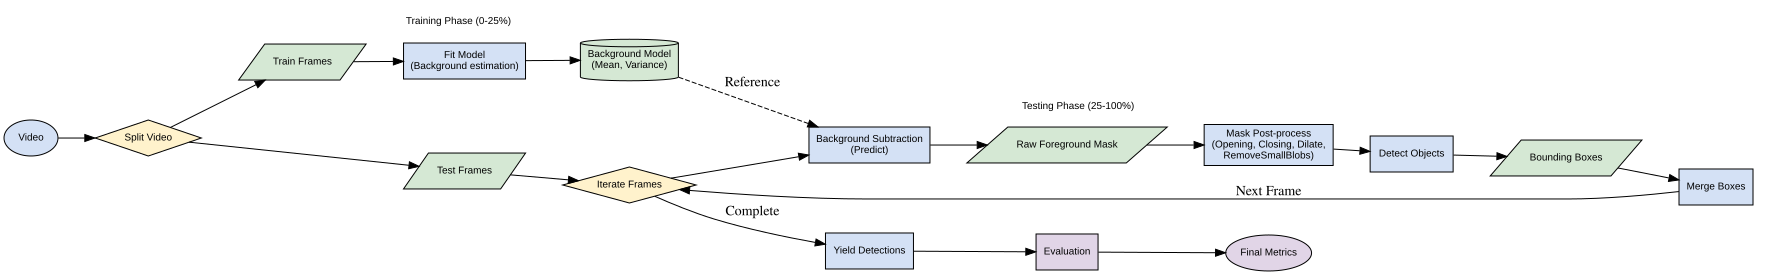

In [13]:
import graphviz
from IPython.display import display

dot = graphviz.Digraph('Detection_Pipeline')

# Set global attributes
dot.attr(bgcolor='white', rankdir='LR', fontname='Arial', compound='true')
dot.attr('node', shape='box', style='filled', color='black', fontname='Arial', fontsize='10')

# Main Entry Point
dot.node('Video', 'Video', shape='ellipse', fillcolor='#D4E1F5')
dot.node('Split', 'Split Video', shape='diamond', fillcolor='#FFF2CC')

# --- TRAINING BRANCH (No Dotted Border) ---
with dot.subgraph(name='cluster_train') as c:
    # Set peripheries to '0' to erase the dotted line
    c.attr(label='Training Phase (0-25%)', peripheries='0', fontname='Arial', fontsize='10')
    c.node('TrainFrames', 'Train Frames', shape='parallelogram', fillcolor='#D5E8D4')
    c.node('Fit', 'Fit Model\n(Background estimation)', fillcolor='#D4E1F5')
    c.node('Model', 'Background Model\n(Mean, Variance)', shape='cylinder', fillcolor='#D5E8D4')
    c.edge('TrainFrames', 'Fit')
    c.edge('Fit', 'Model')

# --- TESTING & DETECTION BRANCH (No Dotted Border) ---
with dot.subgraph(name='cluster_test') as c:
    # Set peripheries to '0' to erase the dotted line
    c.attr(label='Testing Phase (25-100%)', peripheries='0', fontname='Arial', fontsize='10')
    c.node('TestFrames', 'Test Frames', shape='parallelogram', fillcolor='#D5E8D4')
    c.node('Iterate', 'Iterate Frames', shape='diamond', fillcolor='#FFF2CC')
    c.node('Subtract', 'Background Subtraction\n(Predict)', fillcolor='#D4E1F5')
    c.node('RawMask', 'Raw Foreground Mask', shape='parallelogram', fillcolor='#D5E8D4')
    c.node('Postprocess', 'Mask Post-process\n(Opening, Closing, Dilate,\nRemoveSmallBlobs)', fillcolor='#D4E1F5')
    c.node('Detect', 'Detect Objects', fillcolor='#D4E1F5')
    c.node('BBoxes', 'Bounding Boxes', shape='parallelogram', fillcolor='#D5E8D4')
    c.node('Merge', 'Merge Boxes', fillcolor='#D4E1F5')
    
    c.edge('TestFrames', 'Iterate')
    c.edge('Iterate', 'Subtract')
    c.edge('Subtract', 'RawMask')
    c.edge('RawMask', 'Postprocess')
    c.edge('Postprocess', 'Detect')
    c.edge('Detect', 'BBoxes')
    c.edge('BBoxes', 'Merge')
    c.edge('Merge', 'Iterate', label=' Next Frame')

# --- EVALUATION ---
dot.node('Yield', 'Yield Detections', fillcolor='#D4E1F5')
dot.node('Eval', 'Evaluation', fillcolor='#E1D5E7')
dot.node('Metrics', 'Final Metrics', shape='ellipse', fillcolor='#E1D5E7')

# Connections
dot.edge('Video', 'Split')
dot.edge('Split', 'TrainFrames')
dot.edge('Split', 'TestFrames')
dot.edge('Model', 'Subtract', style='dashed', label=' Reference')
dot.edge('Iterate', 'Yield', label=' Complete')
dot.edge('Yield', 'Eval')
dot.edge('Eval', 'Metrics')

display(dot)